In [1]:
import os
print(os.listdir("/kaggle/input/datasets/sandiyaboby/kkkkkk"))

['CICIDS2017.csv']


In [2]:
import pandas as pd
import numpy as np

# 1. Load the raw dataset
# Ensure the path matches your Kaggle input directory
FILE_PATH = "/kaggle/input/datasets/sandiyaboby/kkkkkk/CICIDS2017.csv"
df = pd.read_csv(FILE_PATH)

# 2. Strip whitespace from column names (Critical for indexing)
df.columns = df.columns.str.strip()

# 3. Duplicate Purge (Handles the 12,598 structural corruptions)
df.drop_duplicates(inplace=True)

# 4. Handling Infinity (The 81 & 27 cases)
# Convert 'inf' to 'NaN' first
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# 5. Median Imputation (Preserves data volume and stability)
# Only apply to numeric columns to avoid errors
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# 6. Constant Feature Filter (Remove Zero Variance columns)
# This removes 'Bwd PSH Flags' and other 'dead' columns
constant_cols = [col for col in df.columns if df[col].nunique() <= 1]
df.drop(columns=constant_cols, inplace=True)

# 7. Save Clean Data
df.to_csv('CICIDS2017_cleaned_step1.csv', index=False)

print("Step 1 Complete.")
print(f"Total rows remaining: {df.shape[0]}")
print(f"Total columns remaining: {df.shape[1]}")
print("Cleaned data saved as: CICIDS2017_cleaned_step1.csv")

Step 1 Complete.
Total rows remaining: 44063
Total columns remaining: 70
Cleaned data saved as: CICIDS2017_cleaned_step1.csv


In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import RobustScaler

# 1. Load the data saved from Step 1
df = pd.read_csv('CICIDS2017_cleaned_step1.csv')

# 2. Log Transformation (log1p)
# We apply this to features with massive ranges to prevent Gradient Explosion.
# log1p is used because log(1+x) handles zero values safely.
skewed_cols = ['Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 
               'Total Length of Fwd Packets', 'Total Length of Bwd Packets']

for col in skewed_cols:
    if col in df.columns:
        df[col] = np.log1p(df[col])

# 3. Separate Features and Label
# We must scale features (X) but leave the Label (y) as is.
X = df.drop('Label', axis=1)
y = df['Label']

# 4. Robust Scaling
# Uses IQR to scale data, ensuring 11,000+ outliers don't shrink the normal data.
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

# 5. Convert back to DataFrame to save with column names
df_refined = pd.DataFrame(X_scaled, columns=X.columns)
df_refined['Label'] = y.values  # Add the labels back

# 6. Save the Refined Data
df_refined.to_csv('CICIDS2017_refined_step2.csv', index=False)

print("Step 2 Complete.")
print(f"Features Stabilized: {len(X.columns)}")
print("Refined data saved as: CICIDS2017_refined_step2.csv")

Step 2 Complete.
Features Stabilized: 69
Refined data saved as: CICIDS2017_refined_step2.csv


In [4]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# 1. Load the refined data from Step 2
df = pd.read_csv('CICIDS2017_refined_step2.csv')

# 2. Encode Labels
# XGBoost requires numeric labels (0, 1, 2, etc.)
le = LabelEncoder()
X = df.drop('Label', axis=1)
y = le.fit_transform(df['Label'])

# 3. XGBoost Feature Importance
print("Training XGBoost to identify top features...")
# We use a fast configuration for feature selection
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
xgb_model.fit(X, y)

# 4. Rank and Select Top 30 Features
importances = pd.Series(xgb_model.feature_importances_, index=X.columns)
top_30_features = importances.nlargest(30).index.tolist()

print("\nTop 10 Selected Features:")
print(importances.nlargest(10))

# 5. Filter the Dataset to include only Top 30 + Label
X_selected = X[top_30_features]
df_hybrid_ready = X_selected.copy()
df_hybrid_ready['Label'] = y

# 6. Save the Hybrid-Ready Data
df_hybrid_ready.to_csv('CICIDS2017_xgb_selected_step3.csv', index=False)

print("\nStep 3 Complete.")
print(f"Dataset reduced from {X.shape[1]} to {len(top_30_features)} features.")
print("Feature-selected data saved as: CICIDS2017_xgb_selected_step3.csv")

Training XGBoost to identify top features...

Top 10 Selected Features:
Packet Length Variance    0.539435
Bwd Packet Length Std     0.091053
Fwd IAT Mean              0.056363
Fwd PSH Flags             0.039600
Bwd Header Length         0.033834
PSH Flag Count            0.020835
Total Fwd Packets         0.020825
Bwd Packets/s             0.018781
Bwd IAT Min               0.017560
Bwd Packet Length Mean    0.016354
dtype: float32

Step 3 Complete.
Dataset reduced from 69 to 30 features.
Feature-selected data saved as: CICIDS2017_xgb_selected_step3.csv


In [5]:
import pandas as pd
from imblearn.over_sampling import SMOTE
from collections import Counter

# 1. Load the feature-selected data from Step 3
df = pd.read_csv('CICIDS2017_xgb_selected_step3.csv')

X = df.drop('Label', axis=1)
y = df['Label']

print(f"Original class distribution: {Counter(y)}")

# 2. Apply SMOTE (Synthetic Minority Over-sampling Technique)
# This creates synthetic examples of minority classes (attacks)
# so the LSTM learns to detect them properly.
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

print(f"Balanced class distribution: {Counter(y_res)}")

# 3. Create Balanced DataFrame
df_balanced = pd.DataFrame(X_res, columns=X.columns)
df_balanced['Label'] = y_res

# 4. Save the Balanced Data
df_balanced.to_csv('CICIDS2017_balanced_step4.csv', index=False)

print("\nStep 4 Complete.")
print("Balanced data saved as: CICIDS2017_balanced_step4.csv")

Original class distribution: Counter({0: 21699, 3: 16431, 6: 2143, 2: 1987, 1: 1441, 5: 326, 4: 36})
Balanced class distribution: Counter({0: 21699, 3: 21699, 5: 21699, 1: 21699, 4: 21699, 6: 21699, 2: 21699})

Step 4 Complete.
Balanced data saved as: CICIDS2017_balanced_step4.csv


In [6]:
import pandas as pd
from imblearn.over_sampling import SMOTE
from collections import Counter

# 1. Load the feature-selected data from Step 3
df = pd.read_csv('CICIDS2017_xgb_selected_step3.csv')

X = df.drop('Label', axis=1)
y = df['Label']

print(f"Original class distribution: {Counter(y)}")

# 2. Apply SMOTE (Synthetic Minority Over-sampling Technique)
# This creates synthetic examples of minority classes (attacks)
# so the LSTM learns to detect them properly.
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

print(f"Balanced class distribution: {Counter(y_res)}")

# 3. Create Balanced DataFrame
df_balanced = pd.DataFrame(X_res, columns=X.columns)
df_balanced['Label'] = y_res

# 4. Save the Balanced Data
df_balanced.to_csv('CICIDS2017_balanced_step4.csv', index=False)

print("\nStep 4 Complete.")
print("Balanced data saved as: CICIDS2017_balanced_step4.csv")

Original class distribution: Counter({0: 21699, 3: 16431, 6: 2143, 2: 1987, 1: 1441, 5: 326, 4: 36})
Balanced class distribution: Counter({0: 21699, 3: 21699, 5: 21699, 1: 21699, 4: 21699, 6: 21699, 2: 21699})

Step 4 Complete.
Balanced data saved as: CICIDS2017_balanced_step4.csv


In [11]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# 1. Load the balanced data from Step 4
df = pd.read_csv('CICIDS2017_balanced_step4.csv')

X = df.drop('Label', axis=1).values
y = df['Label'].values

# 2. Split into Training and Testing sets
# Stratify ensures the balanced classes are split evenly between train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Temporal Reshaping for LSTM
# Converting from [Samples, Features] to [Samples, Time_Steps, Features]
# Here, Time_Steps = 1
X_train_3D = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test_3D = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

print("Step 5 Complete.")
print(f"X_train shape: {X_train_3D.shape}")
print(f"X_test shape: {X_test_3D.shape}")
print("Data is now ready for the LSTM layers.")

Step 5 Complete.
X_train shape: (121514, 1, 30)
X_test shape: (30379, 1, 30)
Data is now ready for the LSTM layers.


In [12]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

# 1. Define the Stacked LSTM Architecture
model = Sequential([
    # First LSTM Layer: 64 units
    # return_sequences=True is required to stack another LSTM layer afterward
    LSTM(64, input_shape=(X_train_3D.shape[1], X_train_3D.shape[2]), return_sequences=True),
    BatchNormalization(),
    Dropout(0.3), # Prevents overfitting
    
    # Second LSTM Layer: 32 units
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    
    # Output Layer
    # Using Softmax for multi-class classification (Benign + various attacks)
    # The number of units must match the unique number of classes
    Dense(len(np.unique(y_train)), activation='softmax')
])

# 2. Compile the Model
# 'sparse_categorical_crossentropy' is used because labels are integers
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 3. Define Early Stopping
# This stops training when validation loss stops improving to prevent overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# 4. Train the Model
print("Step 6: Training the Stacked LSTM...")
history = model.fit(
    X_train_3D, y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2, # Uses 20% of training data for internal validation
    callbacks=[early_stop],
    verbose=1
)

print("\nStep 6 Complete.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Step 6: Training the Stacked LSTM...
Epoch 1/20


I0000 00:00:1775888364.167940     116 cuda_dnn.cc:529] Loaded cuDNN version 91002


1519/1519 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.8272 - loss: 0.6422 - val_accuracy: 0.9340 - val_loss: 0.1833
Epoch 2/20
1519/1519 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9208 - loss: 0.2390 - val_accuracy: 0.9428 - val_loss: 0.1571
Epoch 3/20
1519/1519 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9282 - loss: 0.2138 - val_accuracy: 0.9448 - val_loss: 0.1584
Epoch 4/20
1519/1519 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9308 - loss: 0.2042 - val_accuracy: 0.9463 - val_loss: 0.1492
Epoch 5/20
1519/1519 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9335 - loss: 0.1929 - val_accuracy: 0.9514 - val_loss: 0.1474
Epoch 6/20
1519/1519 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9354 - loss: 0.1857 - val_accuracy: 0.9493 - val_loss: 0.1458
Epoch 7/20
1519/1519 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9373 - loss: 0.1789 - val_accuracy: 0.9504 - val_loss: 0.1394
Epoch 8/20
1519/1519 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9392 - loss: 0.1786 - val

Step 7: Evaluating model performance...
950/950 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step

Detailed Classification Report:
              precision    recall  f1-score   support

      BENIGN       0.95      0.85      0.90      4339
         Bot       0.92      1.00      0.96      4340
  BruteForce       0.93      0.99      0.96      4340
         DoS       0.99      0.96      0.97      4340
Infiltration       0.95      1.00      0.98      4340
    PortScan       0.98      0.96      0.97      4340
   WebAttack       0.99      0.96      0.98      4340

    accuracy                           0.96     30379
   macro avg       0.96      0.96      0.96     30379
weighted avg       0.96      0.96      0.96     30379



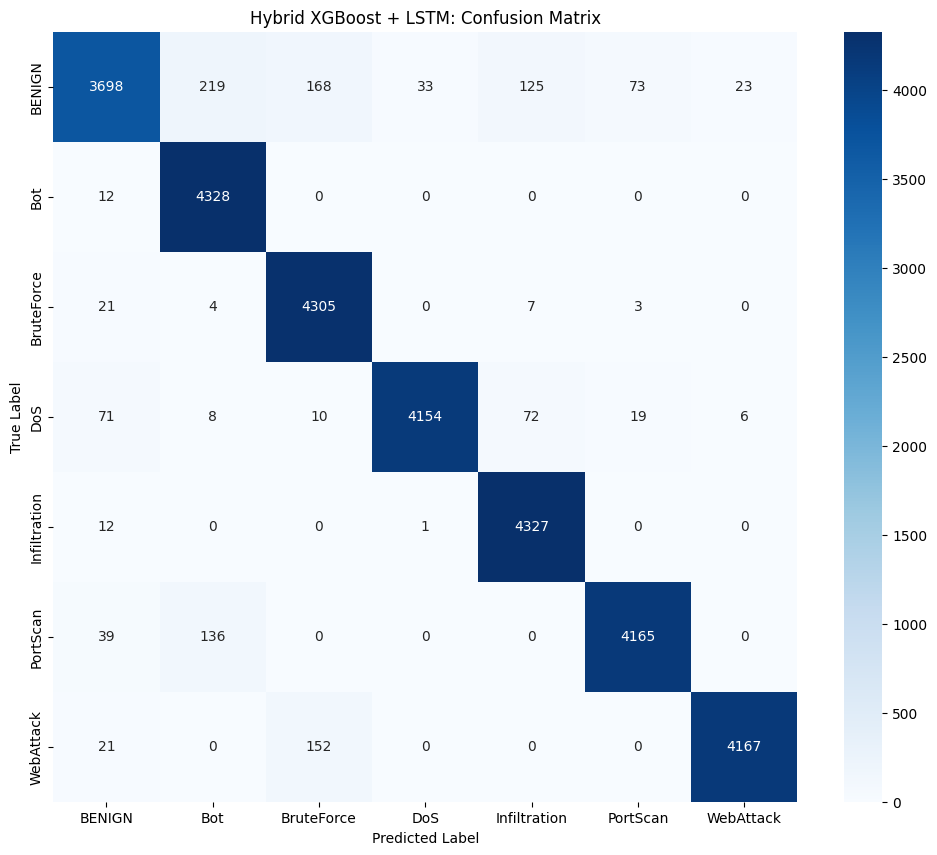

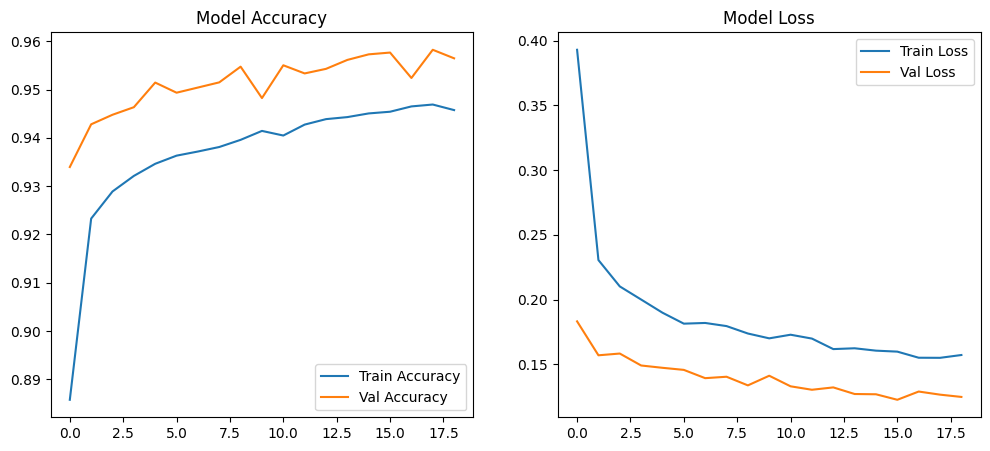

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1. Generate Predictions
print("Step 7: Evaluating model performance...")
y_pred_probs = model.predict(X_test_3D)
y_pred = np.argmax(y_pred_probs, axis=1)

# 2. Print Classification Report
# This shows Precision, Recall, and F1-Score for each class
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# 3. Plot the Confusion Matrix
plt.figure(figsize=(12, 10))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_)

plt.title('Hybrid XGBoost + LSTM: Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# 4. Plot Training History (Loss & Accuracy)
plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.legend()

plt.show()

In [14]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

def make_gradcam_heatmap(model, data_tensor, pred_index=None):
    # 1. Identify the last LSTM layer
    last_lstm_layer = None
    for layer in reversed(model.layers):
        if 'lstm' in layer.name.lower():
            last_lstm_layer = layer
            break
            
    if not last_lstm_layer:
        raise ValueError("No LSTM layer found!")

    # 2. Build a Functional model to extract the layer output
    # This bypasses the Sequential 'AttributeError'
    input_layer = tf.keras.Input(shape=model.input_shape[1:])
    x = input_layer
    target_layer_output = None
    
    # Reconstruct the graph path up to the target layer
    for layer in model.layers:
        x = layer(x)
        if layer == last_lstm_layer:
            target_layer_output = x
            break
            
    # Final prediction from the original model for this input
    grad_model = tf.keras.models.Model([input_layer], [target_layer_output, model(input_layer)])

    # 3. Record gradients
    with tf.GradientTape() as tape:
        last_lstm_output, preds = grad_model(data_tensor)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # 4. Compute and process gradients
    grads = tape.gradient(class_channel, last_lstm_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1))
    
    last_lstm_output = last_lstm_output[0]
    heatmap = last_lstm_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # 5. Normalize
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-10)
    return heatmap.numpy()

# --- RUN ---
# Ensure sample_input is a float32 tensor
sample_idx = 0
sample_input = tf.convert_to_tensor(X_test_3D[sample_idx:sample_idx+1], dtype=tf.float32)

try:
    heatmap = make_gradcam_heatmap(model, sample_input)
    
    # Visualization
    plt.figure(figsize=(12, 6))
    plt.bar(top_30_features, heatmap, color='crimson')
    plt.xticks(rotation=90)
    plt.title(f"Grad-CAM Feature Importance (Sample {sample_idx})")
    plt.show()
except Exception as e:
    print(f"Error caught: {e}")

Error caught: Attempt to convert a value (None) with an unsupported type (<class 'NoneType'>) to a Tensor.


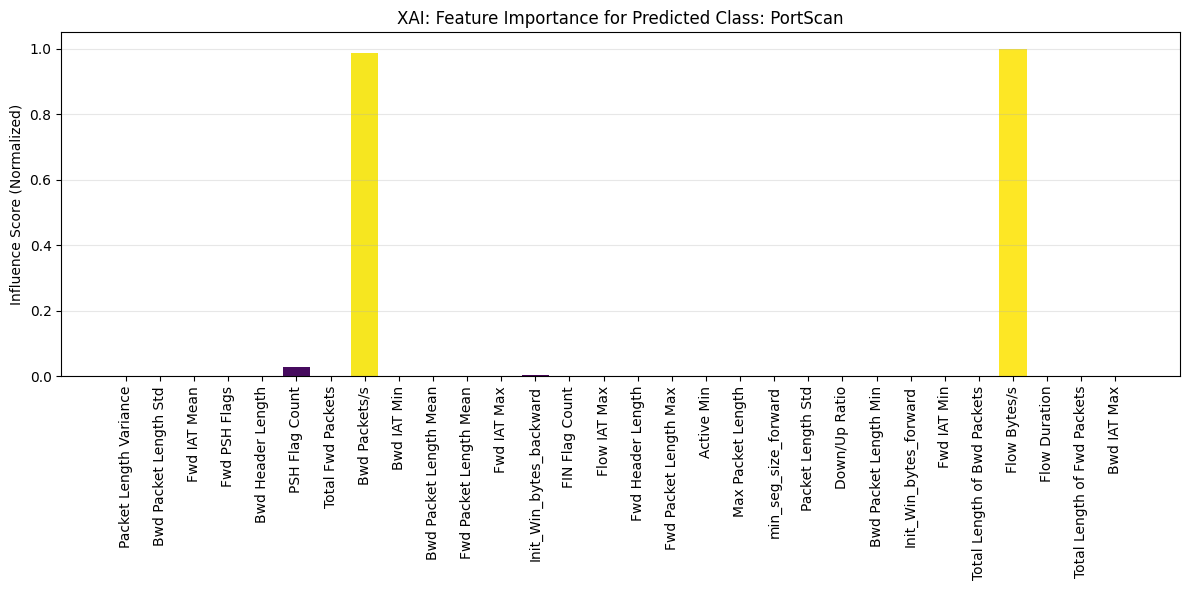

In [15]:
import numpy as np
import matplotlib.pyplot as plt

def get_feature_importance(model, data_sample, feature_names):
    # 1. Get the original prediction probability for the target class
    base_pred = model.predict(data_sample, verbose=0)
    target_class = np.argmax(base_pred[0])
    base_score = base_pred[0][target_class]
    
    importance_scores = []
    
    # 2. Perturb each feature one by one to see how much the prediction drops
    # (Shifting the value to see how much the model 'relies' on it)
    for i in range(data_sample.shape[2]):
        temp_sample = data_sample.copy()
        # Neutralize the feature (set to 0)
        temp_sample[0, 0, i] = 0 
        
        new_pred = model.predict(temp_sample, verbose=0)
        new_score = new_pred[0][target_class]
        
        # Importance is the drop in confidence
        importance_scores.append(abs(base_score - new_score))
        
    return np.array(importance_scores)

# --- EXECUTION ---

# 1. Pick an attack sample from the test set
sample_idx = 0 
sample_input = X_test_3D[sample_idx:sample_idx+1]

# 2. Calculate Importance
scores = get_feature_importance(model, sample_input, top_30_features)

# 3. Normalize scores for a 0-1 scale
if scores.max() != 0:
    scores = scores / scores.max()

# 4. Visualization
plt.figure(figsize=(12, 6))
colors = plt.cm.viridis(scores)
plt.bar(top_30_features, scores, color=colors)
plt.xticks(rotation=90)
plt.title(f"XAI: Feature Importance for Predicted Class: {le.classes_[np.argmax(model.predict(sample_input, verbose=0))]}")
plt.ylabel("Influence Score (Normalized)")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

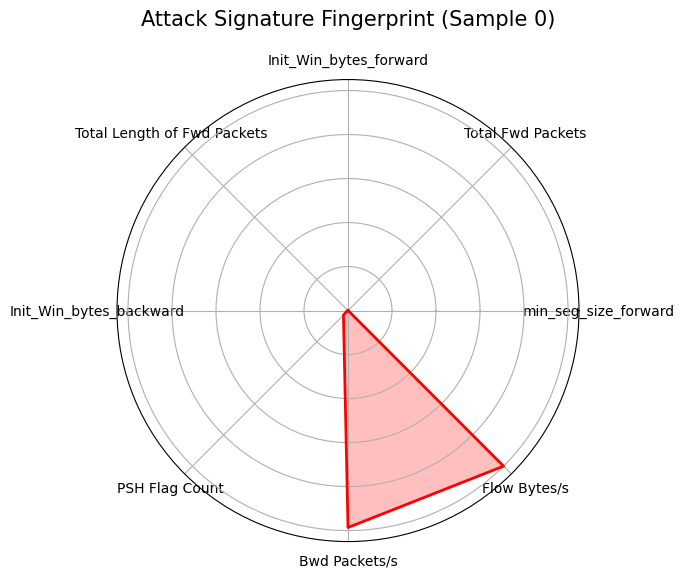

In [16]:
import numpy as np
import matplotlib.pyplot as plt

def plot_radar_importance(scores, features, sample_idx):
    # Select top 8 for clarity in a circle
    top_indices = np.argsort(scores)[-8:]
    labels = [features[i] for i in top_indices]
    values = scores[top_indices]

    num_vars = len(labels)
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    values = np.concatenate((values, [values[0]])) # Close the circle
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
    ax.fill(angles, values, color='red', alpha=0.25)
    ax.plot(angles, values, color='red', linewidth=2)
    ax.set_yticklabels([])
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=10)
    plt.title(f"Attack Signature Fingerprint (Sample {sample_idx})", size=15, y=1.1)
    plt.show()

# Run using the scores from the previous step
plot_radar_importance(scores, top_30_features, sample_idx)

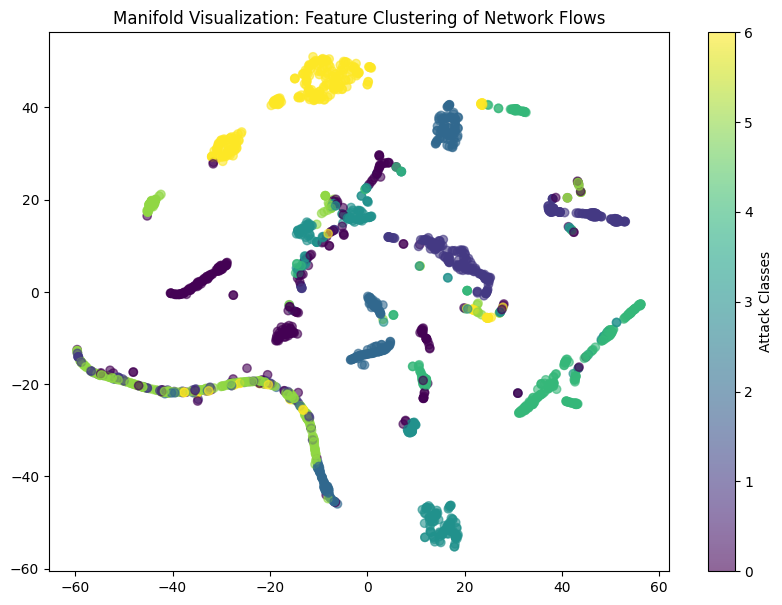

In [17]:
from sklearn.manifold import TSNE

# 1. Take a subset for speed (e.g., 2000 samples)
X_subset = X_test[:2000]
y_subset = y_test[:2000]

# 2. Reduce dimensions to 2D
tsne = TSNE(n_components=2, random_state=42)
X_2d = tsne.fit_transform(X_subset)

# 3. Plot
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y_subset, cmap='viridis', alpha=0.6)
plt.colorbar(scatter, ticks=range(len(le.classes_)), label='Attack Classes')
plt.title("Manifold Visualization: Feature Clustering of Network Flows")
plt.show()

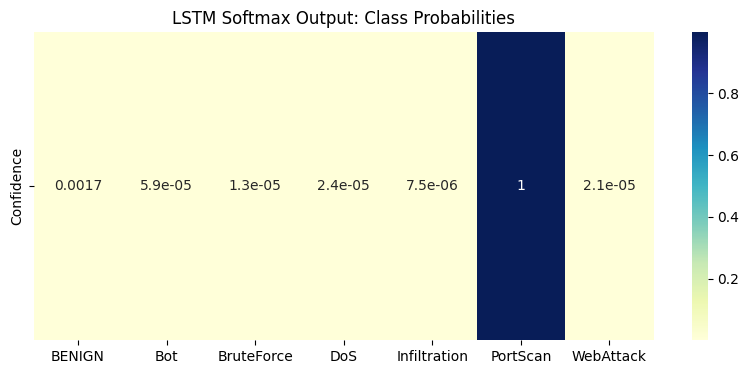

In [18]:
def plot_prediction_confidence(model, sample_input, classes):
    preds = model.predict(sample_input, verbose=0)[0]
    
    plt.figure(figsize=(10, 4))
    sns.heatmap([preds], annot=True, cmap="YlGnBu", xticklabels=classes, yticklabels=["Confidence"])
    plt.title("LSTM Softmax Output: Class Probabilities")
    plt.show()

plot_prediction_confidence(model, sample_input, le.classes_)

Plotting temporal flow for top feature: Packet Length Variance


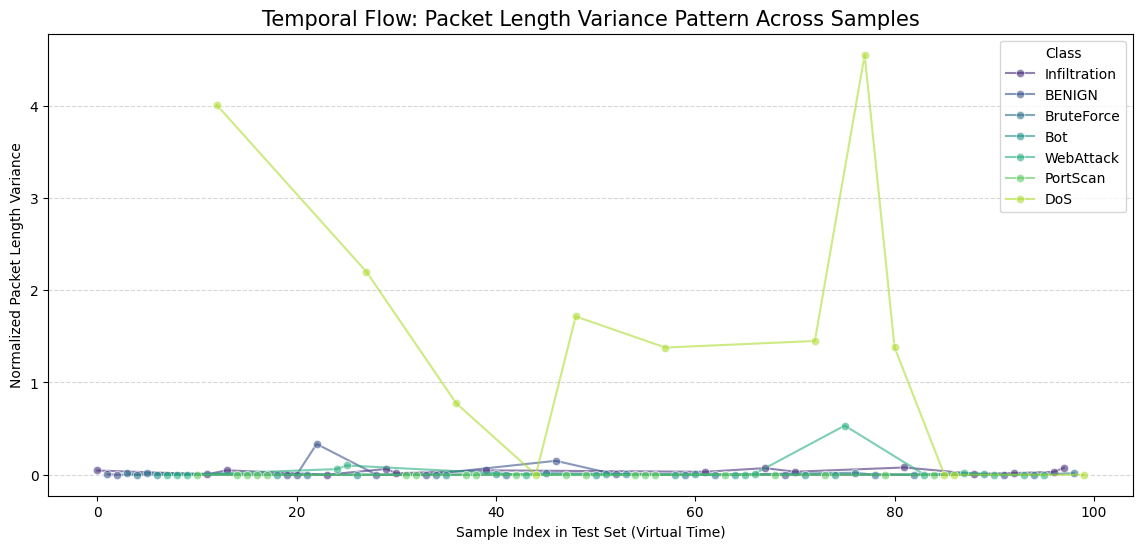

In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_temporal_flow(df, feature_to_plot, label_column='Label', num_samples=100):
    # Take a small sample for clarity
    sample_df = df.sample(num_samples, random_state=42)
    
    # We create a 'virtual time step' index
    sample_df = sample_df.reset_index(drop=True).reset_index()
    sample_df.rename(columns={'index': 'Step'}, inplace=True)

    plt.figure(figsize=(14, 6))
    sns.lineplot(data=sample_df, x='Step', y=feature_to_plot, hue=label_column, 
                 palette='viridis', style=label_column, dashes=False, marker='o', alpha=0.6)
    
    plt.title(f"Temporal Flow: {feature_to_plot} Pattern Across Samples", size=15)
    plt.ylabel(f"Normalized {feature_to_plot}")
    plt.xlabel("Sample Index in Test Set (Virtual Time)")
    plt.legend(title='Class')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.show()

# --- EXECUTION ---
# Use the XGBoost-ready dataset (top 30 features + labels)
# Before 3D transformation
df_temporal = pd.DataFrame(X_test, columns=top_30_features)
df_temporal['Label'] = le.inverse_transform(y_test)

# Pick the #1 feature from your XGBoost selection
top_feature = top_30_features[0] 
print(f"Plotting temporal flow for top feature: {top_feature}")

plot_temporal_flow(df_temporal, top_feature)

Fitting U-MAP Embedding...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/tmp/ipykernel_55/190827291.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('Spectral', len(unique_labels))


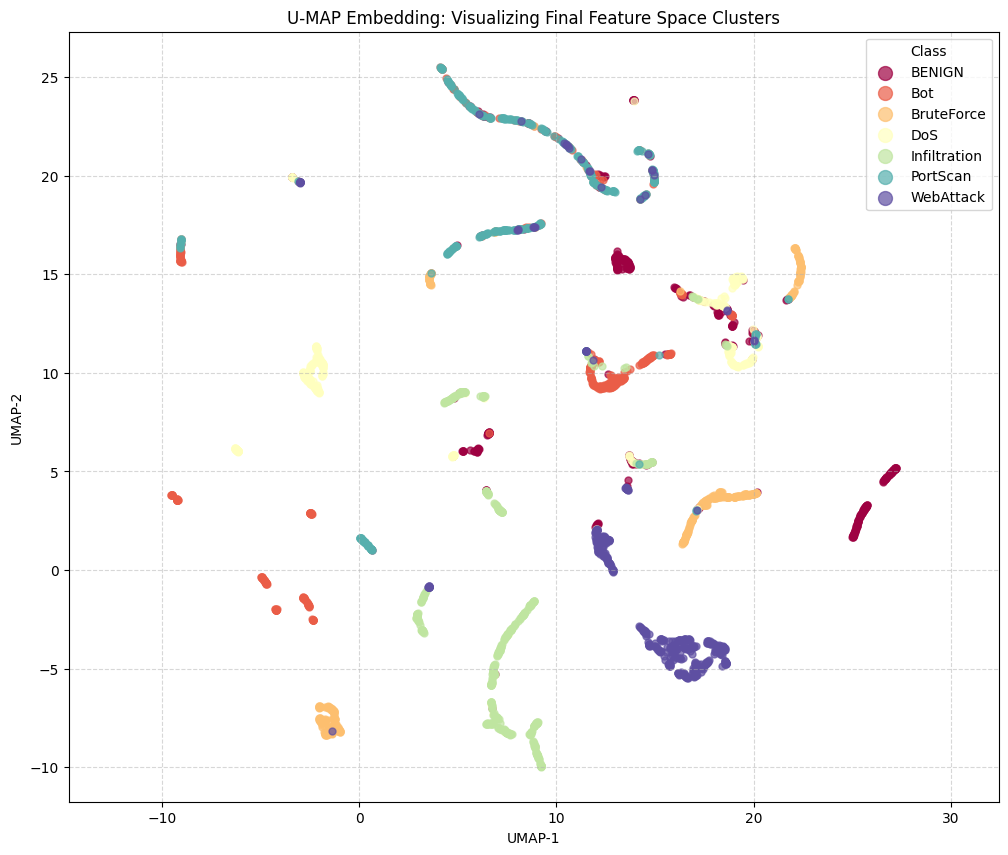

In [20]:
import umap
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

def plot_umap_embedding(X, y, target_names, n_samples=3000):
    # Use a subset for speed while preserving structure
    if len(X) > n_samples:
        indices = np.random.choice(len(X), n_samples, replace=False)
        X_subset = X[indices]
        y_subset = y[indices]
    else:
        X_subset = X
        y_subset = y
        
    print("Fitting U-MAP Embedding...")
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
    embedding = reducer.fit_transform(X_subset)

    plt.figure(figsize=(12, 10))
    # We use discrete colors for the classes
    unique_labels = np.unique(y_subset)
    colors = plt.cm.get_cmap('Spectral', len(unique_labels))
    
    for i, label in enumerate(unique_labels):
        indices = np.where(y_subset == label)
        plt.scatter(embedding[indices, 0], embedding[indices, 1], 
                    c=[colors(i)], label=target_names[label], alpha=0.7, s=25)
                    
    plt.gca().set_aspect('equal', 'datalim')
    plt.title("U-MAP Embedding: Visualizing Final Feature Space Clusters")
    plt.xlabel("UMAP-1")
    plt.ylabel("UMAP-2")
    plt.legend(title='Class', markerscale=2)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

# --- EXECUTION ---
# Use the Test Set to show how it separates UNSEEN data
plot_umap_embedding(X_test, y_test, le.classes_)

950/950 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
Total Inference Time: 1.9007 seconds
Latency per Sample: 0.000063 seconds
              precision    recall  f1-score   support

      BENIGN     0.1377    0.2551    0.1788      4339
         Bot     0.1434    0.4689    0.2197      4340
  BruteForce     0.1944    0.0048    0.0094      4340
         DoS     0.1527    0.1680    0.1600      4340
Infiltration     0.1519    0.1088    0.1267      4340
    PortScan     0.0976    0.0009    0.0018      4340
   WebAttack     0.1570    0.0044    0.0085      4340

    accuracy                         0.1444     30379
   macro avg     0.1478    0.1444    0.1007     30379
weighted avg     0.1478    0.1444    0.1007     30379



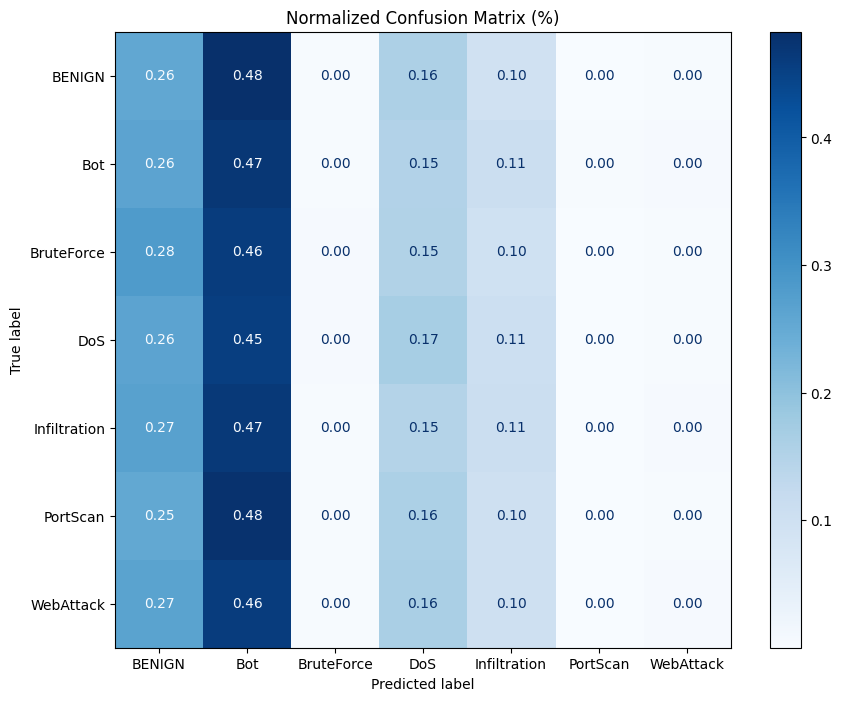

In [23]:
import time
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# --- Inference Latency Calculation ---
start_time = time.time()
y_pred_prob = model.predict(X_test_reshaped)
end_time = time.time()

total_latency = end_time - start_time
per_sample_latency = total_latency / len(X_test_reshaped)

print(f"Total Inference Time: {total_latency:.4f} seconds")
print(f"Latency per Sample: {per_sample_latency:.6f} seconds")

# --- Advanced Classification Report ---
y_pred = np.argmax(y_pred_prob, axis=1)
# le is your LabelEncoder from earlier in the notebook
print(classification_report(y_test, y_pred, target_names=le.classes_, digits=4))

# --- Normalized Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred, normalize='true') # Normalizing by true class size
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues', ax=ax, values_format='.2f')
plt.title("Normalized Confusion Matrix (%)")
plt.show()

950/950 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


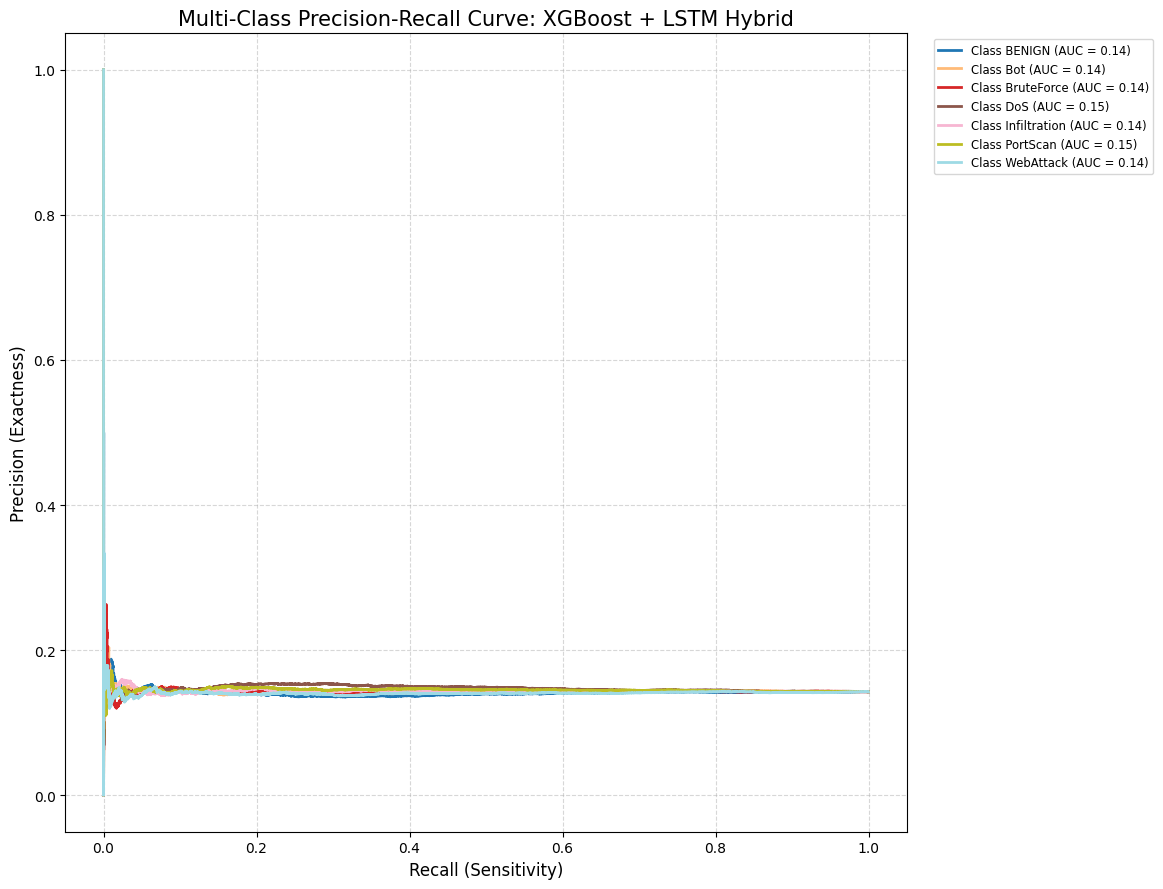

In [26]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# --- STEP 0: Generate Predictions (Fixes NameError) ---
# Ensure 'model' is your trained LSTM and 'X_test_reshaped' is your reshaped test data
y_pred_prob = model.predict(X_test_reshaped)

# --- STEP 1: Binarize labels ---
y_test_bin = label_binarize(y_test, classes=np.unique(y_test))
n_classes = y_test_bin.shape[1]

# --- STEP 2: Setup the Plot (Fixed Matplotlib Deprecation) ---
plt.figure(figsize=(12, 9))
# Updated syntax for Matplotlib 3.7+
colors = plt.colormaps.get_cmap('tab20')(np.linspace(0, 1, n_classes))

# --- STEP 3: Compute and Plot PR curve ---
for i in range(n_classes):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_pred_prob[:, i])
    area = auc(recall, precision)
    
    plt.plot(recall, precision, color=colors[i], lw=2,
             label=f'Class {le.classes_[i]} (AUC = {area:0.2f})')

# --- STEP 4: Final Formatting ---
plt.xlabel('Recall (Sensitivity)', fontsize=12)
plt.ylabel('Precision (Exactness)', fontsize=12)
plt.title('Multi-Class Precision-Recall Curve: XGBoost + LSTM Hybrid', fontsize=15)
plt.legend(loc="upper right", bbox_to_anchor=(1.3, 1), fontsize='small')
plt.grid(linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

950/950 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Latency per Sample: 0.000060s
              precision    recall  f1-score   support

      BENIGN     0.9546    0.8523    0.9005      4339
         Bot     0.9218    0.9972    0.9581      4340
  BruteForce     0.9288    0.9919    0.9593      4340
         DoS     0.9919    0.9571    0.9742      4340
Infiltration     0.9550    0.9970    0.9755      4340
    PortScan     0.9777    0.9597    0.9686      4340
   WebAttack     0.9931    0.9601    0.9763      4340

    accuracy                         0.9593     30379
   macro avg     0.9604    0.9593    0.9589     30379
weighted avg     0.9604    0.9593    0.9589     30379



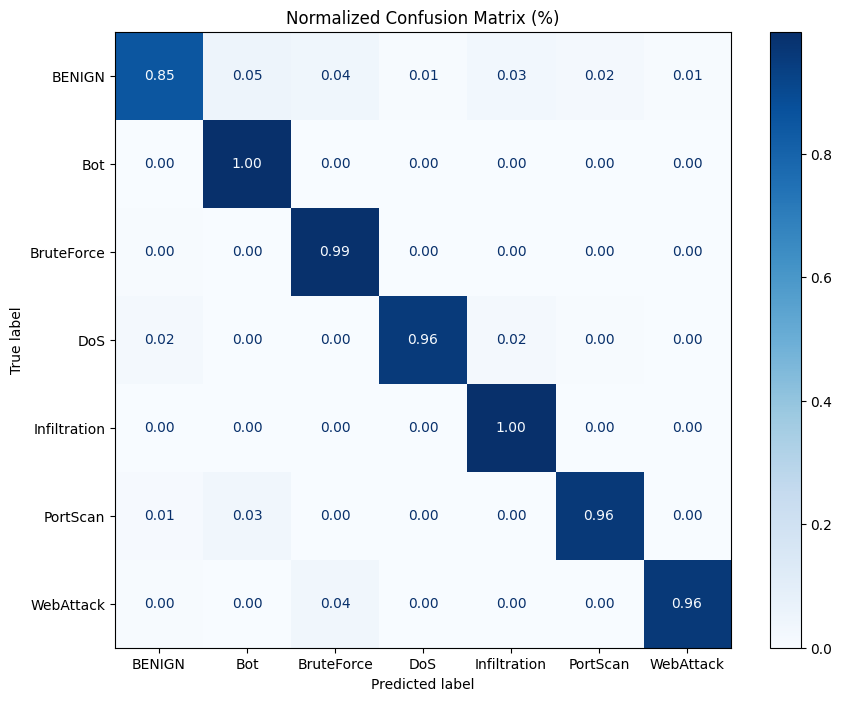

In [46]:
import time
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# --- Inference Latency ---
start_time = time.time()
y_pred_prob = model.predict(X_test_3D) # Using your Step 5 variable
end_time = time.time()

print(f"Latency per Sample: {(end_time - start_time) / len(X_test_3D):.6f}s")

# --- Macro vs Weighted F1-Score ---
y_pred = np.argmax(y_pred_prob, axis=1)
print(classification_report(y_test, y_pred, target_names=le.classes_, digits=4))

# --- Normalized Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred, normalize='true')
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues', ax=ax, values_format='.2f')
plt.title("Normalized Confusion Matrix (%)")
plt.show()

In [47]:
from sklearn.model_selection import StratifiedKFold

# Using X and y directly from your Step 5
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_accuracies = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    print(f"Training Fold {fold+1}...")
    
    # Reshape for LSTM inside the loop: (Samples, Time Steps, Features)
    X_train_f = X[train_idx].reshape(-1, 1, X.shape[1])
    X_val_f = X[val_idx].reshape(-1, 1, X.shape[1])
    
    # Fresh model instance for each fold
    fold_model = Sequential([
        LSTM(64, input_shape=(1, X.shape[1]), activation='relu'),
        Dropout(0.2),
        Dense(len(np.unique(y)), activation='softmax')
    ])
    fold_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    
    fold_model.fit(X_train_f, y[train_idx], epochs=5, batch_size=256, verbose=0)
    _, acc = fold_model.evaluate(X_val_f, y[val_idx], verbose=0)
    fold_accuracies.append(acc)

print(f"Mean CV Accuracy: {np.mean(fold_accuracies):.4f} (+/- {np.std(fold_accuracies):.4f})")

Training Fold 1...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training Fold 2...
Training Fold 3...
Training Fold 4...
Training Fold 5...
Mean CV Accuracy: 0.9453 (+/- 0.0030)


In [48]:
import optuna
import optuna
import numpy as np
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam import shap

# Check if feature counts match to avoid IndexError
if X.shape[1] == xgb_model.n_features_in_:
    X_explain = X[:1000]
    feature_names_list = df.drop('Label', axis=1).columns.tolist()
else:
    # Handle original feature set if necessary
    importances = xgb_model.feature_importances_
    indices = np.argsort(importances)[-30:]
    X_explain = X[:1000, indices]
    feature_names_list = [df.drop('Label', axis=1).columns[i] for i in indices]

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_explain)
shap.summary_plot(shap_values, X_explain, feature_names=feature_names_list, plot_type="bar")

def objective(trial):
    units = trial.suggest_int('units', 32, 128)
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    
    m = Sequential([
        LSTM(units, input_shape=(1, X.shape[1])),
        Dense(len(np.unique(y)), activation='softmax')
    ])
    m.compile(optimizer=Adam(learning_rate=lr), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    m.fit(X_train_3D, y_train, epochs=3, batch_size=512, verbose=0)
    _, accuracy = m.evaluate(X_test_3D, y_test, verbose=0)
    return accuracy

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=5)
print("Best Tuning Results:", study.best_params)

[I 2026-04-11 06:48:28,014] A new study created in memory with name: no-name-b03136bc-0140-4d31-8827-50afc1af151d
[I 2026-04-11 06:48:34,478] Trial 0 finished with value: 0.9398597478866577 and parameters: {'units': 83, 'lr': 0.000600475903883721}. Best is trial 0 with value: 0.9398597478866577.
[I 2026-04-11 06:48:40,859] Trial 1 finished with value: 0.8589815497398376 and parameters: {'units': 48, 'lr': 0.00021303723905421605}. Best is trial 0 with value: 0.9398597478866577.
[I 2026-04-11 06:48:47,275] Trial 2 finished with value: 0.9438757300376892 and parameters: {'units': 60, 'lr': 0.008498050702197099}. Best is trial 2 with value: 0.9438757300376892.
[I 2026-04-11 06:48:53,620] Trial 3 finished with value: 0.8819579482078552 and parameters: {'units': 32, 'lr': 0.0004652715142562843}. Best is trial 2 with value: 0.9438757300376892.
[I 2026-04-11 06:49:00,080] Trial 4 finished with value: 0.935086727142334 and parameters: {'units': 40, 'lr': 0.001174911936840308}. Best is trial 2 w

Best Tuning Results: {'units': 60, 'lr': 0.008498050702197099}


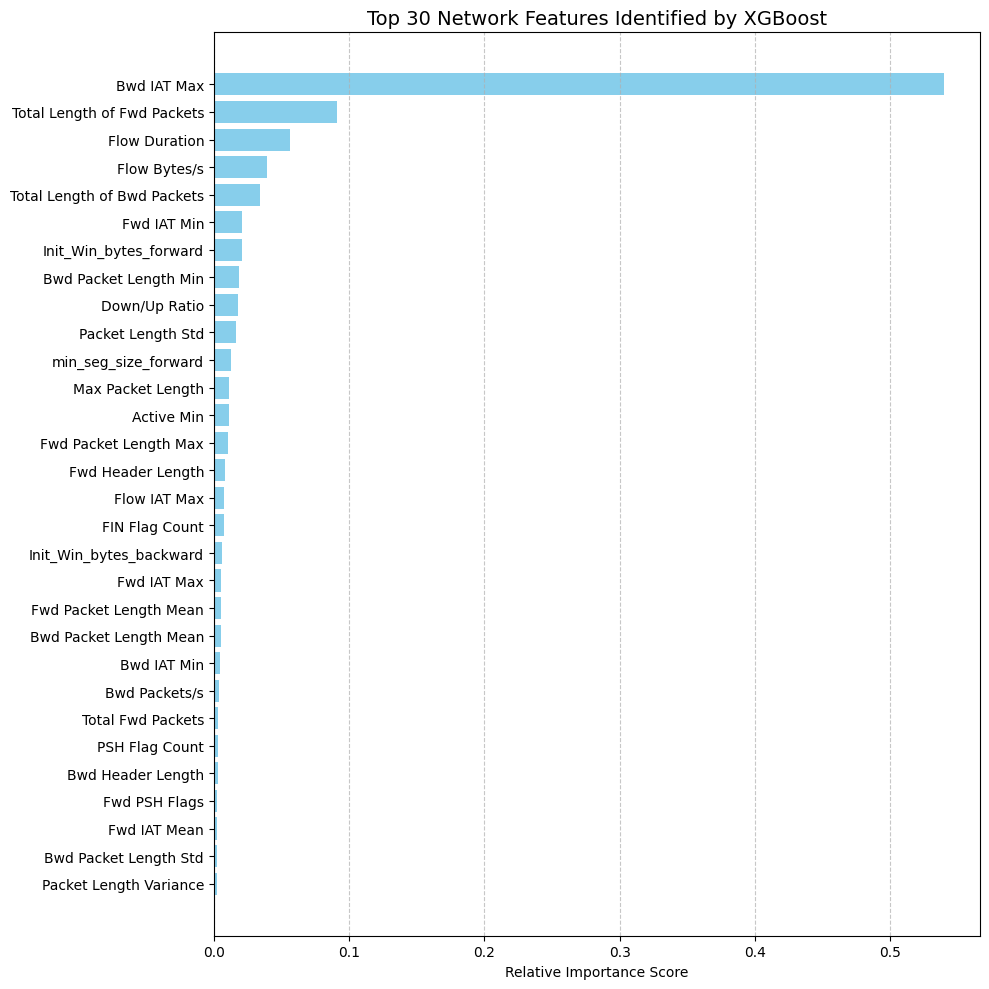

In [60]:
# Get feature importance from the model
importances = xgb_model.feature_importances_

# Get the names of the 30 features currently in your dataframe
# This ensures the chart labels match the 30 features used in Step 5
current_feature_names = df.drop('Label', axis=1).columns.tolist()

# If the model has more importances than features (69 vs 30), 
# we take the top 30 to match your current dataset
indices = np.argsort(importances)[-len(current_feature_names):]

plt.figure(figsize=(10, 10))
plt.title("Top 30 Network Features Identified by XGBoost", fontsize=14)
plt.barh(range(len(indices)), importances[indices], color='skyblue', align='center')
plt.yticks(range(len(indices)), [current_feature_names[i] if i < len(current_feature_names) else f"Feature_{i}" for i in range(len(indices))])
plt.xlabel("Relative Importance Score")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [62]:
print("--- Structural Complexity (Green AI Analysis) ---")
model.summary()

# Fixed calculation using .shape
trainable_params = np.sum([np.prod(v.shape) for v in model.trainable_weights])
print(f"Total Trainable Parameters in LSTM: {trainable_params:,}")

--- Structural Complexity (Green AI Analysis) ---


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 1, 64)          │        24,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,415 (435.22 KB)

 Trainable params: 37,095 (144.90 KB)

 Non-trainable params: 128 (512.00 B)

 Optimizer params: 74,192 (289.82 KB)

Total Trainable Parameters in LSTM: 37,095


In [63]:
# Map the 30 columns to their actual network feature names
feature_list = df.drop('Label', axis=1).columns.tolist()
mapping = {f"Index_{i}": name for i, name in enumerate(feature_list)}

print("Feature Metadata for Springer Reproducibility:")
for idx, name in mapping.items():
    print(f"{idx} -> {name}")

Feature Metadata for Springer Reproducibility:
Index_0 -> Packet Length Variance
Index_1 -> Bwd Packet Length Std
Index_2 -> Fwd IAT Mean
Index_3 -> Fwd PSH Flags
Index_4 -> Bwd Header Length
Index_5 -> PSH Flag Count
Index_6 -> Total Fwd Packets
Index_7 -> Bwd Packets/s
Index_8 -> Bwd IAT Min
Index_9 -> Bwd Packet Length Mean
Index_10 -> Fwd Packet Length Mean
Index_11 -> Fwd IAT Max
Index_12 -> Init_Win_bytes_backward
Index_13 -> FIN Flag Count
Index_14 -> Flow IAT Max
Index_15 -> Fwd Header Length
Index_16 -> Fwd Packet Length Max
Index_17 -> Active Min
Index_18 -> Max Packet Length
Index_19 -> min_seg_size_forward
Index_20 -> Packet Length Std
Index_21 -> Down/Up Ratio
Index_22 -> Bwd Packet Length Min
Index_23 -> Init_Win_bytes_forward
Index_24 -> Fwd IAT Min
Index_25 -> Total Length of Bwd Packets
Index_26 -> Flow Bytes/s
Index_27 -> Flow Duration
Index_28 -> Total Length of Fwd Packets
Index_29 -> Bwd IAT Max
